# Random Positioning Machine Simulator - Python Notebook Version

This notebook is a Python/Jupyter companion to the HTML Random Positioning Machine simulator. It keeps the same scientific goals while using Python tools instead of browser/HTML code.

It models a two-axis RPM holding a square agar plate with Arabidopsis seedlings, computes sample-frame gravity over time, compares static/random/microgravity/biased partial-gravity runs, checks physical sample-point accelerations across the plate, and exports figures/data for review or microcontroller planning.

**Important:** this file is separate from `index.html`; running or editing it will not affect the HTML simulator.

**How to read this notebook if you do not code often:** run the cells from top to bottom. The early cells define tools and functions; they usually do not display much. The later "Example Run" cells are where you choose the simulation settings, make plots, and export files.

## What This Notebook Includes

- Static, random-walk, microgravity-optimized, and biased partial-gravity scenarios
- Outer and inner gimbal rotations with velocity and acceleration limits
- Optional centrifugal and Coriolis acceleration terms
- Plate, inner rotator, and outer rotator dimensions in metric units
- Center, corner, grid, or custom sample-point acceleration analysis
- Moving-window gravity analysis over biologically meaningful time scales
- Target validation for zero-g, Moon, Mars, or arbitrary target gravity levels
- 3D plots of the gimbal, plate, gravity vectors, sample paths, and sampled gravity sphere
- PDF report export on normal letter-size pages with vector-style Matplotlib plots
- CSV command schedule and Arduino-style pseudocode export for machine builders
- Biology-focused exposure reports, warnings, replicate checks, hardware feasibility checks, log import, and methods-text export

## Before You Run This On Your Own Computer

Most people only need to change a few things:

1. **Install Python packages.** If a cell fails with `ModuleNotFoundError`, install the missing package. In a terminal or Anaconda Prompt, try:

```bash
pip install numpy pandas matplotlib ipywidgets
```

If you use Anaconda, most of these are already installed.

2. **Open the notebook from the folder where you want outputs saved.** The export cell writes files into a folder named `rpm_notebook_outputs` beside this notebook by default.

3. **Change paths only in the export cell.** Search for `out_dir = Path("rpm_notebook_outputs")`. You can replace that with your own folder, for example:

```python
out_dir = Path("/Users/yourname/Desktop/rpm_results")      # macOS example
out_dir = Path("C:/Users/yourname/Desktop/rpm_results")   # Windows example
```

4. **Change experiment settings in the Example Run cell.** Search for `cfg = preset_config("microgravity")`. That is the main place to choose Moon, Mars, static control, duration, plate size, motor limits, and other user-facing settings.

5. **You usually do not need to edit the function-definition cells.** They are heavily commented so you can understand them, but the safest workflow is to change settings in the Example Run and Export cells first.

In [62]:
# -----------------------------------------------------------------------------
# SETUP CELL: imports, constants, and plotting defaults
# -----------------------------------------------------------------------------
# Run this cell first. It loads the Python libraries used everywhere else.
# If this cell errors on another computer, that usually means a package is not
# installed yet. Install missing packages with:
#     pip install numpy pandas matplotlib ipywidgets
#
# Beginner note:
# - Lines that start with # are comments. Python ignores them.
# - Comments are here to explain the code; they do not change the simulation.

# Standard Python libraries:
# json = saving and loading reproducible config files.
# math = trigonometry and constants such as pi.
# platform/datetime = recording reproducibility metadata.
# time = measuring how long a simulation takes.
# dataclass/replace = convenient way to store experiment settings and state.
# Path = safer file/folder paths than plain text strings.
# Iterable = type hint used for values that can be looped over.
import json
import math
import platform
import time
from datetime import datetime
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Iterable

# Scientific Python libraries:
# numpy is used for vectors, matrices, and numerical calculations.
# pandas is used for spreadsheet-like result tables.
# matplotlib is used for plots and PDF figure export.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401; activates 3D projections

# IPython display helpers make pandas tables render nicely in notebooks.
# If someone runs this as a plain .py script instead of in Jupyter, the fallback
# makes display(...) behave like print(...).
try:
    from IPython.display import display, clear_output
except Exception:
    display = print
    clear_output = lambda *args, **kwargs: None

# ipywidgets is optional. If it is installed, the final dashboard cell works.
# If it is not installed, the rest of the notebook still works normally.
try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

# Physical/math constants used throughout the notebook.
G = 9.80665  # acceleration due to gravity on Earth, in meters per second squared
DEG = math.pi / 180.0  # multiply degrees by this to convert degrees -> radians

# Gravity in the fixed world coordinate system. Here, world Z points up/down, so
# gravity points in the negative Z direction. The vector length is 1 because we
# express gravity in "g units" rather than m/s^2 for most plots.
WORLD_G = np.array([0.0, 0.0, -1.0])

# Geometry of the simulated two-axis RPM.
# OUTER_AXIS_WORLD is horizontal, so the outer ring actually changes the gravity
# direction experienced by the sample. If this were vertical, the gravity path
# would collapse into a flatter 2D-looking trace.
OUTER_AXIS_WORLD = np.array([0.0, 1.0, 0.0])
INNER_AXIS_OUTER = np.array([1.0, 0.0, 0.0])

# Direction used for biased partial-gravity targets such as Moon or Mars gravity.
TARGET_DIR = np.array([0.0, 0.0, -1.0])

# Random-number generator. Keeping a fixed seed makes examples reproducible.
RNG = np.random.default_rng(42)

# Matplotlib plot defaults. Change these only if you want different plot sizes,
# resolution, grid visibility, or font size.
plt.rcParams.update({
    "figure.figsize": (8.5, 5.2),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

In [63]:
# -----------------------------------------------------------------------------
# CONFIGURATION CELL: all user-adjustable simulation settings live here
# -----------------------------------------------------------------------------
# You normally do not edit the class definition itself. Instead, use the
# Example Run cell later and write something like:
#     cfg = preset_config("microgravity").copy(duration_days=1.0)
# That makes a copy of the preset and changes only the values you specify.

@dataclass
class RPMConfig:
    """All model parameters for one RPM experiment.

    Units are metric unless stated otherwise. Angles entered in degrees are converted
    to radians internally by the simulation functions.
    """

    # Scenario controls the behavior of the virtual motors:
    # - "static": no rotation, useful as a 1g control
    # - "random": smooth random motion with no target correction
    # - "micro": tries to make the long-term average gravity approach 0g
    # - "biased": tries to approach a nonzero target such as Moon or Mars gravity
    scenario: str = "micro"

    # duration_days is the simulated experiment length. Small values run quickly.
    # dt is the simulation time step in seconds. Smaller dt = more detail but slower.
    duration_days: float = 0.01
    dt: float = 0.25

    # Motor motion limits. These are in degrees/second or degrees/second^2 because
    # those are easier for humans and motor specs; the code converts to radians.
    random_turn_strength_deg_s: float = 7.0
    max_angular_velocity_deg_s: float = 40.0
    max_angular_acceleration_deg_s2: float = 8.0
    rotation_limit_deg: float = 180.0

    # Bias settings for partial gravity. target_g is the desired short-window average:
    # 0.0 = microgravity, 0.166 = Moon-like, 0.38 = Mars-like, 1.0 = Earth-like.
    bias_strength: float = 3.0
    target_g: float = 0.0

    # Partial-gravity controller settings. For a nonzero target, the simulator now
    # tries to keep instantaneous gravity on a cone: gz near -target_g while gx/gy
    # keep rotating and average out. target_settle_s is the time scale that should
    # approach the requested average; 300 seconds is 5 minutes.
    target_settle_s: float = 300.0
    min_continuous_spin_deg_s: float = 8.0
    cone_tracking_weight: float = 12.0

    # Physical RPM/plate dimensions. Change these to match your actual device.
    # These values matter for centrifugal acceleration and builder-facing plots.
    plate_side_mm: float = 90.0
    inner_rotator_diameter_mm: float = 160.0
    outer_rotator_diameter_mm: float = 260.0
    sample_offset_mm: float = 0.0

    # Extra acceleration terms. Centrifugal is usually worth keeping on.
    # Coriolis is off by default because the seedlings/plate points are treated as
    # rigidly mounted rather than flowing through the sample frame.
    include_centrifugal: bool = True
    include_coriolis: bool = False

    # Long biological experiments can be many days. Fast runs coarsen the output
    # cadence so a notebook cell finishes quickly while preserving the requested duration.
    max_fast_steps: int = 25000

    # Builder / microcontroller planning parameters. Change these if your motor,
    # gearing, encoder, or control loop are different.
    control_hz: float = 20.0
    steps_per_rev: int = 200
    gear_ratio: float = 20.0
    encoder_counts: int = 4096
    backlash_deg: float = 0.2
    angle_noise_deg: float = 0.05
    timing_jitter_ms: float = 2.0

    @property
    def duration_s(self) -> float:
        """Return duration in seconds because the simulator steps forward in seconds."""
        return float(self.duration_days) * 24.0 * 3600.0

    def copy(self, **updates):
        """Make a modified copy without changing the original preset."""
        return replace(self, **updates)


def preset_config(name: str) -> RPMConfig:
    """Convenience presets for common demonstrations."""
    key = name.lower().strip()
    if key in {"zero", "0g", "micro", "microgravity"}:
        return RPMConfig(scenario="micro", target_g=0.0, bias_strength=0.0,
                         random_turn_strength_deg_s=8.0,
                         max_angular_velocity_deg_s=40.0,
                         max_angular_acceleration_deg_s2=6.0)
    if key in {"moon", "lunar"}:
        return RPMConfig(scenario="biased", target_g=0.166, bias_strength=5.0, target_settle_s=300.0)
    if key == "mars":
        return RPMConfig(scenario="biased", target_g=0.38, bias_strength=5.0, target_settle_s=300.0)
    if key in {"static", "control"}:
        return RPMConfig(scenario="static", target_g=1.0, bias_strength=0.0)
    raise ValueError(f"Unknown preset: {name}")

In [64]:
# -----------------------------------------------------------------------------
# GEOMETRY/MATH HELPER CELL
# -----------------------------------------------------------------------------
# These functions are the small mathematical building blocks used by the RPM
# model. You usually do not need to change them unless you are changing the
# physical geometry of the simulated machine.

def clamp(value, lo, hi):
    """Keep value between lo and hi."""
    return max(lo, min(hi, value))


def wrap_angle_rad(angle):
    """Wrap any angle into the range -pi to +pi radians."""
    return (angle + math.pi) % (2.0 * math.pi) - math.pi


def rotation_matrix_axis_angle(axis, angle):
    """Rodrigues rotation matrix for rotating around any 3D axis.

    A rotation matrix is a compact way to rotate a vector in 3D. Here it is used
    to rotate the plate/gimbal axes and to ask: "where does gravity point from
    the sample's point of view?"
    """
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    c = math.cos(angle)
    s = math.sin(angle)
    C = 1.0 - c
    return np.array([
        [c + x*x*C, x*y*C - z*s, x*z*C + y*s],
        [y*x*C + z*s, c + y*y*C, y*z*C - x*s],
        [z*x*C - y*s, z*y*C + x*s, c + z*z*C],
    ])


def sample_rotation_matrix(theta_outer, theta_inner):
    """Return sample-to-world rotation for a two-axis gimbal.

    The outer ring rotates about a horizontal world Y axis. The inner ring rotates about
    the outer ring's local X axis, so both RPM axes change the sample-frame gravity vector.
    """
    r_outer = rotation_matrix_axis_angle(OUTER_AXIS_WORLD, theta_outer)
    inner_axis_world = r_outer @ INNER_AXIS_OUTER
    r_inner_world = rotation_matrix_axis_angle(inner_axis_world, theta_inner)
    return r_inner_world @ r_outer


def gravity_for_angles(theta_outer, theta_inner):
    """World gravity expressed in sample coordinates, in units of g.

    This is one of the core scientific outputs. It answers: if the machine is at
    these two angles, what x/y/z gravity vector does the sample experience?
    """
    r_sample_to_world = sample_rotation_matrix(theta_outer, theta_inner)
    return r_sample_to_world.T @ WORLD_G


def random_unit_vector(rng=RNG):
    """Return a random 3D direction with length 1."""
    v = rng.normal(size=3)
    return v / np.linalg.norm(v)

In [65]:
# -----------------------------------------------------------------------------
# STATE AND MOTION CELL
# -----------------------------------------------------------------------------
# "Config" stores the experiment settings. "State" stores where the RPM is right
# now: current angles, speeds, previous speeds, and running average gravity.

@dataclass
class RPMState:
    # Current outer/inner angles, in radians.
    theta_outer: float = 0.0
    theta_inner: float = 0.0

    # Current outer/inner angular velocities, in radians per second.
    omega_outer: float = 0.0
    omega_inner: float = 0.0

    # Previous velocities are kept so acceleration can be estimated.
    prev_omega_outer: float = 0.0
    prev_omega_inner: float = 0.0

    # Running average of the sample-frame gravity vector over the full run.
    avg_g: np.ndarray = None

    # Rolling-window average used by the target-G controller. This prevents the
    # solver from front-loading a high-g transient and then stopping. It asks:
    # "what has the sample felt over the most recent target_settle_s seconds?"
    window_avg_g: np.ndarray = None
    recent_g: tuple = ()
    recent_sum_g: np.ndarray = None
    steps: int = 0

    def __post_init__(self):
        # dataclasses should not use a mutable array as a direct default, so we
        # create fresh zero vectors when a new RPMState is made.
        if self.avg_g is None:
            self.avg_g = np.zeros(3)
        if self.window_avg_g is None:
            self.window_avg_g = np.zeros(3)
        if self.recent_sum_g is None:
            self.recent_sum_g = np.zeros(3)


def angular_vector_sample(state: RPMState):
    """Approximate angular velocity vector in sample coordinates."""
    r = sample_rotation_matrix(state.theta_outer, state.theta_inner)
    r_outer = rotation_matrix_axis_angle(OUTER_AXIS_WORLD, state.theta_outer)
    inner_axis_world = r_outer @ INNER_AXIS_OUTER
    omega_world = state.omega_outer * OUTER_AXIS_WORLD + state.omega_inner * inner_axis_world
    return r.T @ omega_world


def local_acceleration_at(point_sample_m, state: RPMState, cfg: RPMConfig, dt: float):
    """Total acceleration at a plate point, in sample coordinates and units of g.

    Gravity is always 1 g instantaneously. Centrifugal and Coriolis-like terms
    can introduce small plate-position-dependent differences.
    """
    # Start with the gravity vector experienced by the sample.
    g_sample = gravity_for_angles(state.theta_outer, state.theta_inner)
    total = np.array(g_sample, dtype=float)

    # Estimate rotational acceleration terms. These are small for many RPMs but
    # useful when checking whether different parts of the plate feel different.
    omega = angular_vector_sample(state)
    alpha = np.array([
        (state.omega_inner - state.prev_omega_inner) / max(dt, 1e-9),
        0.0,
        (state.omega_outer - state.prev_omega_outer) / max(dt, 1e-9),
    ])
    r = np.asarray(point_sample_m, dtype=float)

    if cfg.include_centrifugal:
        total += -np.cross(omega, np.cross(omega, r)) / G
    if cfg.include_coriolis:
        # For a rigidly mounted sample point, relative velocity is near zero.
        # This term is kept as an optional placeholder for moving samples/fluids.
        v_relative = np.zeros(3)
        total += -2.0 * np.cross(omega, v_relative) / G
    return total


def candidate_step(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG):
    """Generate one smooth random-walk candidate step.

    Velocity targets persist for enough time to avoid frame-to-frame jitter. The
    acceleration cap then limits how fast the motors can reach those targets.
    """
    max_w = cfg.max_angular_velocity_deg_s * DEG
    max_a = cfg.max_angular_acceleration_deg_s2 * DEG
    turn_strength = cfg.random_turn_strength_deg_s * DEG

    # Pick new target motor speeds with a bit of randomness.
    target_outer = state.omega_outer + rng.normal(0.0, turn_strength * math.sqrt(dt))
    target_inner = state.omega_inner + rng.normal(0.0, turn_strength * math.sqrt(dt))

    # If the combined speed is too high, scale both axes down together.
    speed = math.hypot(target_outer, target_inner)
    if speed > max_w:
        target_outer *= max_w / speed
        target_inner *= max_w / speed

    # Limit how quickly speeds are allowed to change.
    dw_outer = clamp(target_outer - state.omega_outer, -max_a * dt, max_a * dt)
    dw_inner = clamp(target_inner - state.omega_inner, -max_a * dt, max_a * dt)

    # Build the next state without overwriting the current one.
    next_state = replace(state)
    next_state.prev_omega_outer = state.omega_outer
    next_state.prev_omega_inner = state.omega_inner
    next_state.omega_outer = clamp(state.omega_outer + dw_outer, -max_w, max_w)
    next_state.omega_inner = clamp(state.omega_inner + dw_inner, -max_w, max_w)
    next_state.theta_outer = wrap_angle_rad(state.theta_outer + next_state.omega_outer * dt)
    next_state.theta_inner = wrap_angle_rad(state.theta_inner + next_state.omega_inner * dt)

    # Optional angle limits for machines that cannot rotate freely through 360 degrees.
    if cfg.rotation_limit_deg < 180.0:
        lim = cfg.rotation_limit_deg * DEG
        next_state.theta_outer = clamp(next_state.theta_outer, -lim, lim)
        next_state.theta_inner = clamp(next_state.theta_inner, -lim, lim)
    return next_state


def choose_biased_candidate(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG, n_candidates=36):
    """Choose a moving partial-gravity step for a requested nonzero target.

    Older versions optimized the full-run cumulative average. That could create
    an unrealistic pattern: high gravity early, then almost no motion while the
    total average happened to equal the target. This version uses two safeguards:

    1. A real rolling average over approximately `cfg.target_settle_s` seconds
       must approach the requested vector.
    2. Instantaneous gravity is kept near a cone where the downward component is
       target_g, while the sideways x/y components keep rotating and cancel out.
    """
    target_mag = clamp(float(cfg.target_g), 0.0, 1.0)
    target_vec = TARGET_DIR * target_mag
    window_steps = max(1, int(round(cfg.target_settle_s / max(dt, 1e-9))))
    min_spin = cfg.min_continuous_spin_deg_s * DEG

    best_state = None
    best_score = float("inf")

    for _ in range(n_candidates):
        cand = candidate_step(state, cfg, dt, rng)
        g = gravity_for_angles(cand.theta_outer, cand.theta_inner)

        # Predict the true rolling average if this candidate is chosen.
        if len(state.recent_g) >= window_steps:
            prospective_sum = state.recent_sum_g - state.recent_g[0] + g
            prospective_n = window_steps
        else:
            prospective_sum = state.recent_sum_g + g
            prospective_n = len(state.recent_g) + 1
        prospective_window_avg = prospective_sum / max(prospective_n, 1)

        # Downward gravity component in g units. Because TARGET_DIR is [0, 0, -1],
        # this is 1 when gravity points straight down in the sample frame.
        down_component = float(np.dot(g, TARGET_DIR))

        # Sideways part of the recent average should cancel toward zero. The
        # instantaneous sideways component is allowed and expected; it is what
        # keeps the vector moving around the cone.
        sideways_window_error = np.linalg.norm(prospective_window_avg[:2])
        window_vector_error = np.linalg.norm(prospective_window_avg - target_vec)
        cone_error = abs(down_component - target_mag)

        # Keep both axes moving. Penalize candidates that slow the machine below
        # the requested continuous spin speed.
        spin_speed = math.hypot(cand.omega_outer, cand.omega_inner)
        spin_penalty = max(0.0, min_spin - spin_speed) / max(min_spin, 1e-9)

        # Prefer continuing around the cone instead of sitting on one point.
        previous_g = state.recent_g[-1] if state.recent_g else g
        motion_bonus = np.linalg.norm(g - previous_g)

        score = (
            2.0 * window_vector_error
            + cfg.cone_tracking_weight * cone_error
            + 1.0 * sideways_window_error
            + 0.75 * spin_penalty
            - 0.03 * motion_bonus
        )

        if score < best_score:
            best_state = cand
            best_score = score
    return best_state


def choose_microgravity_candidate(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG, n_candidates=16):
    """Bias random motion toward cancelling the current cumulative gravity average."""
    best_state = None
    best_score = float("inf")

    # For microgravity, the best long-term average is near zero. This function
    # chooses motions that pull the cumulative average back toward zero while
    # still exploring different orientations on the sphere.
    for _ in range(n_candidates):
        cand = candidate_step(state, cfg, dt, rng)
        g = gravity_for_angles(cand.theta_outer, cand.theta_inner)
        prospective_avg = (state.avg_g * state.steps + g) / (state.steps + 1)
        coverage_bonus = 0.01 * np.dot(g, random_unit_vector(rng))
        score = np.linalg.norm(prospective_avg) - coverage_bonus
        if score < best_score:
            best_state = cand
            best_score = score
    return best_state


def integrate_step(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG):
    """Advance the machine by one time step and update running average gravity."""
    if cfg.scenario == "static":
        next_state = replace(state)
        next_state.prev_omega_outer = state.omega_outer
        next_state.prev_omega_inner = state.omega_inner
        next_state.omega_outer = 0.0
        next_state.omega_inner = 0.0
    elif cfg.scenario == "biased":
        next_state = choose_biased_candidate(state, cfg, dt, rng)
    elif cfg.scenario in {"micro", "zero", "0g"}:
        next_state = choose_microgravity_candidate(state, cfg, dt, rng)
    else:
        next_state = candidate_step(state, cfg, dt, rng)

    # Convert the new angles into the sample-frame gravity vector.
    g = gravity_for_angles(next_state.theta_outer, next_state.theta_inner)

    # Update the full-run average without needing to store every previous vector.
    next_state.steps = state.steps + 1
    next_state.avg_g = (state.avg_g * state.steps + g) / next_state.steps

    # Update the rolling-window average used for "average over the most recent
    # 5 minutes" behavior in biased partial-gravity runs. This is also recorded
    # in df so the plot can show whether the recent average is on target.
    window_steps = max(1, int(round(cfg.target_settle_s / max(dt, 1e-9))))
    recent = state.recent_g + (g,)
    recent_sum = state.recent_sum_g + g
    if len(recent) > window_steps:
        recent_sum = recent_sum - recent[0]
        recent = recent[1:]
    next_state.recent_g = recent
    next_state.recent_sum_g = recent_sum
    next_state.window_avg_g = recent_sum / max(len(recent), 1)
    return next_state, g

In [66]:
# -----------------------------------------------------------------------------
# RUN_EXPERIMENT_EXPLANATION
# SIMULATION LOOP CELL
# -----------------------------------------------------------------------------
# This function is the engine of the notebook. It repeatedly advances the RPM by
# one time step, records the gravity vector and motion values, then returns:
# - df: a pandas DataFrame, like a spreadsheet of simulation results
# - meta: a dictionary containing settings and extra arrays used by plots
#
# Beginner note: you usually call this function later with:
#     df, meta = run_experiment(cfg, seed=42, fast=True)
# You usually do not edit the loop itself.
def run_experiment(cfg: RPMConfig, seed=42, fast=True, progress=True):
    """Run a complete RPM experiment and return a pandas DataFrame plus metadata."""
    rng = np.random.default_rng(seed)
    dt = float(cfg.dt)
    if fast and cfg.duration_s / dt > cfg.max_fast_steps:
        dt = cfg.duration_s / cfg.max_fast_steps
    n_steps = max(1, int(math.ceil(cfg.duration_s / dt)))

    state = RPMState()
    rows = []
    heat_bins = np.zeros((36, 18), dtype=int)
    t0 = time.time()

    for i in range(n_steps):
        state, g_sample = integrate_step(state, cfg, dt, rng)
        center_acc = local_acceleration_at([0, 0, cfg.sample_offset_mm / 1000.0], state, cfg, dt)
        omega_mag = math.hypot(state.omega_outer, state.omega_inner)
        alpha_outer = (state.omega_outer - state.prev_omega_outer) / max(dt, 1e-9)
        alpha_inner = (state.omega_inner - state.prev_omega_inner) / max(dt, 1e-9)
        alpha_mag = math.hypot(alpha_outer, alpha_inner)

        lon = math.atan2(g_sample[1], g_sample[0])
        lat = math.asin(clamp(g_sample[2] / max(np.linalg.norm(g_sample), 1e-12), -1, 1))
        lon_i = int(((lon + math.pi) / (2 * math.pi)) * heat_bins.shape[0]) % heat_bins.shape[0]
        lat_i = int(((lat + math.pi/2) / math.pi) * heat_bins.shape[1])
        lat_i = max(0, min(heat_bins.shape[1] - 1, lat_i))
        heat_bins[lon_i, lat_i] += 1

        rows.append({
            "time_s": i * dt,
            "time_hr": i * dt / 3600.0,
            "outer_angle_deg": state.theta_outer / DEG,
            "inner_angle_deg": state.theta_inner / DEG,
            "gx": g_sample[0], "gy": g_sample[1], "gz": g_sample[2],
            "g_mag": float(np.linalg.norm(g_sample)),
            "avg_gx": state.avg_g[0], "avg_gy": state.avg_g[1], "avg_gz": state.avg_g[2],
            "avg_g_mag": float(np.linalg.norm(state.avg_g)),
            "window_avg_gx": state.window_avg_g[0], "window_avg_gy": state.window_avg_g[1], "window_avg_gz": state.window_avg_g[2],
            "window_avg_g_mag": float(np.linalg.norm(state.window_avg_g)),
            "omega_outer_deg_s": state.omega_outer / DEG,
            "omega_inner_deg_s": state.omega_inner / DEG,
            "omega_mag_deg_s": omega_mag / DEG,
            "alpha_outer_deg_s2": alpha_outer / DEG,
            "alpha_inner_deg_s2": alpha_inner / DEG,
            "alpha_mag_deg_s2": alpha_mag / DEG,
            "center_total_accel_g": float(np.linalg.norm(center_acc)),
            "extra_accel_g": float(abs(np.linalg.norm(center_acc) - 1.0)),
        })

        if progress and n_steps > 5000 and i % max(1, n_steps // 10) == 0:
            print(f"{100*i/n_steps:5.1f}% complete")

    df = pd.DataFrame(rows)
    meta = {
        "dt_used_s": dt,
        "n_steps": n_steps,
        "runtime_s": time.time() - t0,
        "heat_bins": heat_bins,
        "config": cfg,
    }
    return df, meta

In [67]:
# -----------------------------------------------------------------------------
# VALIDATION_EXPLANATION
# ANALYSIS CELL: target checks, sample points, and builder metrics
# -----------------------------------------------------------------------------
# These functions turn the raw simulation table into easier-to-read summaries.
# They answer questions like:
# - How close did the long-term average gravity get to the target?
# - Did the gravity vector cover the orientation sphere evenly?
# - Do corners of the agar plate feel meaningfully different acceleration?
# - What motor step rate might a builder need?
def target_vector(cfg: RPMConfig):
    return TARGET_DIR * float(cfg.target_g)


def moving_average_worst(df, window_s, component_cols=("gx", "gy", "gz")):
    if len(df) < 2:
        return np.nan, np.array([np.nan, np.nan, np.nan])
    dt = float(np.median(np.diff(df["time_s"])))
    win = max(1, int(round(window_s / max(dt, 1e-9))))
    roll = df[list(component_cols)].rolling(win, min_periods=1).mean()
    mags = np.linalg.norm(roll.values, axis=1)
    idx = int(np.nanargmax(mags))
    return float(mags[idx]), roll.iloc[idx].values


def time_to_within(df, target_mag, tolerance_fraction, column="avg_g_mag", min_time_s=0.0):
    """First time a selected average magnitude is within tolerance of the target.

    min_time_s is useful for rolling-window metrics. For example, a 5-minute
    average should not claim success after only 20 seconds of data.
    """
    target = max(abs(target_mag), 1e-9)
    error = np.abs(df[column].values - target) / target
    eligible = df["time_s"].values >= float(min_time_s)
    ok = np.where((error <= tolerance_fraction) & eligible)[0]
    return float(df["time_s"].iloc[ok[0]]) if len(ok) else np.nan


def orientation_uniformity(meta):
    heat = meta["heat_bins"].astype(float)
    used = heat[heat > 0]
    coverage = float((heat > 0).sum() / heat.size)
    cv = float(used.std() / used.mean()) if len(used) else np.nan
    return {"sphere_bin_coverage_fraction": coverage, "occupied_bin_cv": cv}


def target_validation(df, meta):
    cfg = meta["config"]
    target = target_vector(cfg)
    avg_vec = df[["avg_gx", "avg_gy", "avg_gz"]].iloc[-1].values
    window_avg_vec = df[["window_avg_gx", "window_avg_gy", "window_avg_gz"]].iloc[-1].values
    instant = df[["gx", "gy", "gz"]].values
    running = df[["avg_gx", "avg_gy", "avg_gz"]].values
    window_running = df[["window_avg_gx", "window_avg_gy", "window_avg_gz"]].values
    error_vec = running - target
    window_error_vec = window_running - target
    rms_error = float(np.sqrt(np.mean(np.sum(error_vec**2, axis=1))))
    window_rms_error = float(np.sqrt(np.mean(np.sum(window_error_vec**2, axis=1))))
    final_mag = float(np.linalg.norm(avg_vec))
    target_mag = float(np.linalg.norm(target))
    settle_s = float(getattr(cfg, "target_settle_s", 0.0))
    percent_error = 100.0 * abs(final_mag - target_mag) / max(target_mag, 1e-9)

    windows = {
        "10 s": 10,
        "1 min": 60,
        "10 min": 600,
        "1 hr": 3600,
        "full": max(float(df["time_s"].iloc[-1]), 1.0),
    }
    window_rows = []
    for label, seconds in windows.items():
        mag, vec = moving_average_worst(df, seconds)
        window_rows.append({"window": label, "worst_avg_g_mag": mag,
                            "x": vec[0], "y": vec[1], "z": vec[2]})

    drift = float(np.linalg.norm(running[-1] - running[len(running)//2])) if len(running) > 2 else np.nan
    uniformity = orientation_uniformity(meta)
    summary = {
        "final_average_g_magnitude": final_mag,
        "final_average_vector_x": avg_vec[0],
        "final_average_vector_y": avg_vec[1],
        "final_average_vector_z": avg_vec[2],
        "target_g_magnitude": target_mag,
        "final_window_average_g_magnitude": float(np.linalg.norm(window_avg_vec)),
        "final_window_average_vector_x": window_avg_vec[0],
        "final_window_average_vector_y": window_avg_vec[1],
        "final_window_average_vector_z": window_avg_vec[2],
        "percent_error_from_target": percent_error,
        "rms_vector_error_g": rms_error,
        "window_rms_vector_error_g": window_rms_error,
        "window_time_to_within_10_percent_s": time_to_within(df, target_mag, 0.10, "window_avg_g_mag", settle_s) if target_mag > 0 else np.nan,
        "window_time_to_within_5_percent_s": time_to_within(df, target_mag, 0.05, "window_avg_g_mag", settle_s) if target_mag > 0 else np.nan,
        "window_time_to_within_1_percent_s": time_to_within(df, target_mag, 0.01, "window_avg_g_mag", settle_s) if target_mag > 0 else np.nan,
        "full_run_time_to_within_10_percent_s": time_to_within(df, target_mag, 0.10) if target_mag > 0 else np.nan,
        "full_run_time_to_within_5_percent_s": time_to_within(df, target_mag, 0.05) if target_mag > 0 else np.nan,
        "full_run_time_to_within_1_percent_s": time_to_within(df, target_mag, 0.01) if target_mag > 0 else np.nan,
        "mid_to_final_avg_vector_drift_g": drift,
        **uniformity,
    }
    return pd.Series(summary), pd.DataFrame(window_rows)


def selected_sample_points(cfg: RPMConfig, mode="grid", custom_points_mm=None, grid_n=5):
    half = cfg.plate_side_mm / 2.0
    if mode == "center":
        pts = [("center", 0.0, 0.0)]
    elif mode == "corners":
        pts = [("corner_NE", half, half), ("corner_NW", -half, half),
               ("corner_SW", -half, -half), ("corner_SE", half, -half), ("center", 0.0, 0.0)]
    elif mode == "custom" and custom_points_mm:
        pts = [(f"custom_{i+1}", x, y) for i, (x, y) in enumerate(custom_points_mm)]
    else:
        coords = np.linspace(-half, half, grid_n)
        pts = [(f"grid_{ix}_{iy}", x, y) for ix, x in enumerate(coords) for iy, y in enumerate(coords)]
    return pd.DataFrame(pts, columns=["point", "x_mm", "y_mm"])


def sample_point_analysis(df, meta, mode="grid", custom_points_mm=None, grid_n=5):
    cfg = meta["config"]
    pts = selected_sample_points(cfg, mode, custom_points_mm, grid_n)
    dt = meta["dt_used_s"]
    # Use a representative subset for long runs to keep analysis quick.
    subset = df.iloc[np.linspace(0, len(df)-1, min(len(df), 2000)).astype(int)]
    records = []
    for _, p in pts.iterrows():
        mags = []
        cent_terms = []
        for _, row in subset.iterrows():
            state = RPMState(theta_outer=row.outer_angle_deg*DEG, theta_inner=row.inner_angle_deg*DEG,
                             omega_outer=row.omega_outer_deg_s*DEG, omega_inner=row.omega_inner_deg_s*DEG)
            r = np.array([p.x_mm/1000.0, p.y_mm/1000.0, cfg.sample_offset_mm/1000.0])
            acc = local_acceleration_at(r, state, cfg, dt)
            mags.append(np.linalg.norm(acc))
            omega = angular_vector_sample(state)
            cent = -np.cross(omega, np.cross(omega, r)) / G
            cent_terms.append(np.linalg.norm(cent))
        records.append({
            "point": p.point,
            "x_mm": p.x_mm,
            "y_mm": p.y_mm,
            "mean_accel_g": float(np.mean(mags)),
            "min_accel_g": float(np.min(mags)),
            "max_accel_g": float(np.max(mags)),
            "range_g": float(np.max(mags) - np.min(mags)),
            "worst_centrifugal_g": float(np.max(cent_terms)),
        })
    out = pd.DataFrame(records)
    center_mean = out.loc[out["point"].eq("center"), "mean_accel_g"]
    center = float(center_mean.iloc[0]) if len(center_mean) else float(out["mean_accel_g"].mean())
    summary = pd.Series({
        "selected_points": len(out),
        "center_acceleration_g": center,
        "selected_point_min_g": float(out["mean_accel_g"].min()),
        "selected_point_max_g": float(out["mean_accel_g"].max()),
        "selected_point_mean_g": float(out["mean_accel_g"].mean()),
        "acceleration_range_across_points_g": float(out["mean_accel_g"].max() - out["mean_accel_g"].min()),
        "corner_or_custom_vs_center_difference_g": float(np.max(np.abs(out["mean_accel_g"] - center))),
        "worst_case_centrifugal_g": float(out["worst_centrifugal_g"].max()),
        "gradient_significance": "negligible (<0.001 g)" if float(out["mean_accel_g"].max() - out["mean_accel_g"].min()) < 0.001 else "measureable",
    })
    return out, summary


def builder_metrics(cfg: RPMConfig):
    motor_steps_per_output_rev = cfg.steps_per_rev * cfg.gear_ratio
    steps_per_degree = motor_steps_per_output_rev / 360.0
    encoder_counts_per_degree = cfg.encoder_counts / 360.0
    max_step_rate = steps_per_degree * cfg.max_angular_velocity_deg_s
    max_step_accel = steps_per_degree * cfg.max_angular_acceleration_deg_s2
    return pd.Series({
        "control_loop_hz": cfg.control_hz,
        "control_loop_period_ms": 1000.0 / cfg.control_hz,
        "steps_per_output_degree": steps_per_degree,
        "encoder_counts_per_degree": encoder_counts_per_degree,
        "max_commanded_speed_deg_s": cfg.max_angular_velocity_deg_s,
        "max_motor_step_rate_steps_s": max_step_rate,
        "max_motor_step_accel_steps_s2": max_step_accel,
        "backlash_allowance_deg": cfg.backlash_deg,
        "angle_noise_deg": cfg.angle_noise_deg,
        "timing_jitter_ms": cfg.timing_jitter_ms,
        "inner_rotator_diameter_mm": cfg.inner_rotator_diameter_mm,
        "outer_rotator_diameter_mm": cfg.outer_rotator_diameter_mm,
    })

In [68]:
# -----------------------------------------------------------------------------
# PLOT_EXPLANATION
# PLOTTING CELL
# -----------------------------------------------------------------------------
# These functions make the figures. They do not change the simulation results;
# they only visualize the DataFrame created by run_experiment().
#
# If plots look too small or too large on your machine, adjust figsize values in
# this cell or the Matplotlib defaults in the first setup cell.
def plot_time_series(df, cfg=None):
    fig, axes = plt.subplots(5, 1, figsize=(8.5, 10.5), sharex=True, constrained_layout=True)
    axes[0].plot(df.time_hr, df.gx, label="gx")
    axes[0].plot(df.time_hr, df.gy, label="gy")
    axes[0].plot(df.time_hr, df.gz, label="gz")
    axes[0].set_ylabel("instantaneous g")
    axes[0].legend(ncol=3)

    axes[1].plot(df.time_hr, df.avg_g_mag, color="black", label="full-run avg")
    if "window_avg_g_mag" in df.columns:
        axes[1].plot(df.time_hr, df.window_avg_g_mag, color="tab:green", alpha=0.85, label="short-window avg")
    if cfg is not None:
        axes[1].axhline(cfg.target_g, color="tab:red", ls="--", label="target")
    axes[1].legend()
    axes[1].set_ylabel("average |g|")

    axes[2].plot(df.time_hr, df.center_total_accel_g, color="tab:purple")
    axes[2].set_ylabel("center total |a| g")

    axes[3].plot(df.time_hr, df.omega_outer_deg_s, label="outer")
    axes[3].plot(df.time_hr, df.omega_inner_deg_s, label="inner")
    axes[3].set_ylabel("deg/s")
    axes[3].legend(ncol=2)

    axes[4].plot(df.time_hr, df.alpha_outer_deg_s2, label="outer")
    axes[4].plot(df.time_hr, df.alpha_inner_deg_s2, label="inner")
    axes[4].set_ylabel("deg/s²")
    axes[4].set_xlabel("time (hours)")
    axes[4].legend(ncol=2)
    return fig


def plot_gravity_sphere(df, meta=None, stride=None):
    if stride is None:
        stride = max(1, len(df)//2500)
    pts = df[["gx", "gy", "gz"]].iloc[::stride].values
    fig = plt.figure(figsize=(8.5, 7.0), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")
    u = np.linspace(0, 2*np.pi, 48)
    v = np.linspace(0, np.pi, 24)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(x, y, z, color="0.75", linewidth=0.35, alpha=0.5)
    ax.plot(pts[:,0], pts[:,1], pts[:,2], color="tab:green", lw=0.8, alpha=0.75, label="sample-frame gravity path")
    ax.scatter(pts[:1,0], pts[:1,1], pts[:1,2], color="tab:blue", s=40, label="start")
    ax.scatter(pts[-1:,0], pts[-1:,1], pts[-1:,2], color="tab:red", s=40, label="end")
    ax.quiver(0,0,0, df.avg_gx.iloc[-1], df.avg_gy.iloc[-1], df.avg_gz.iloc[-1], color="black", linewidth=2, label="final average")
    ax.set(xlim=(-1,1), ylim=(-1,1), zlim=(-1,1), xlabel="sample X", ylabel="sample Y", zlabel="sample Z")
    ax.set_box_aspect((1,1,1))
    ax.legend(loc="upper left")
    return fig


def plot_gimbal_3d(df, cfg: RPMConfig, index=-1):
    row = df.iloc[index]
    r = sample_rotation_matrix(row.outer_angle_deg*DEG, row.inner_angle_deg*DEG)
    plate_half = cfg.plate_side_mm / 2000.0
    corners = np.array([[-plate_half,-plate_half,0], [plate_half,-plate_half,0],
                        [plate_half,plate_half,0], [-plate_half,plate_half,0], [-plate_half,-plate_half,0]])
    world_corners = (r @ corners.T).T
    fig = plt.figure(figsize=(8.5, 6.5), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(world_corners[:,0], world_corners[:,1], world_corners[:,2], color="tab:orange", lw=3, label="agar plate")

    # Draw outer and inner rings as simple 3D circles.
    circle = np.linspace(0, 2*np.pi, 160)
    outer_rad = cfg.outer_rotator_diameter_mm / 2000.0
    inner_rad = cfg.inner_rotator_diameter_mm / 2000.0
    outer_world = np.c_[outer_rad*np.cos(circle), np.zeros_like(circle), outer_rad*np.sin(circle)]
    ax.plot(outer_world[:,0], outer_world[:,1], outer_world[:,2], color="tab:red", lw=2, label="outer ring")
    inner = np.c_[np.zeros_like(circle), inner_rad*np.cos(circle), inner_rad*np.sin(circle)]
    inner_world = (r @ inner.T).T
    ax.plot(inner_world[:,0], inner_world[:,1], inner_world[:,2], color="tab:blue", lw=2, label="inner ring")

    origin = np.zeros(3)
    axes = r @ np.eye(3)
    colors = ["crimson", "seagreen", "royalblue"]
    labels = ["sample X", "sample Y", "sample Z"]
    for vec, color, label in zip(axes.T, colors, labels):
        ax.quiver(*origin, *vec, length=outer_rad*0.55, color=color, label=label)
    ax.set(xlabel="world X (m)", ylabel="world Y (m)", zlabel="world Z (m)")
    lim = outer_rad * 1.15
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1,1,1))
    ax.legend(loc="upper left")
    return fig


def plot_force_map(df, meta, mode="grid", grid_n=21):
    cfg = meta["config"]
    half = cfg.plate_side_mm / 2.0
    xs = np.linspace(-half, half, grid_n)
    ys = np.linspace(-half, half, grid_n)
    sample_df = df.iloc[np.linspace(0, len(df)-1, min(len(df), 800)).astype(int)]
    z = np.zeros((grid_n, grid_n))
    for iy, y in enumerate(ys):
        for ix, x in enumerate(xs):
            vals = []
            for _, row in sample_df.iterrows():
                state = RPMState(theta_outer=row.outer_angle_deg*DEG, theta_inner=row.inner_angle_deg*DEG,
                                 omega_outer=row.omega_outer_deg_s*DEG, omega_inner=row.omega_inner_deg_s*DEG)
                acc = local_acceleration_at([x/1000.0, y/1000.0, cfg.sample_offset_mm/1000.0], state, cfg, meta["dt_used_s"])
                vals.append(np.linalg.norm(acc) - 1.0)
            z[iy, ix] = np.mean(vals)
    fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
    im = ax.imshow(z, extent=[-half, half, -half, half], origin="lower", cmap="coolwarm", aspect="equal")
    ax.set_xlabel("plate X (mm)")
    ax.set_ylabel("plate Y (mm)")
    ax.set_title("Mean extra acceleration across agar plate (g above/below 1g)")
    fig.colorbar(im, ax=ax, label="mean extra g")
    return fig


def plot_orientation_heatmap(meta):
    heat = meta["heat_bins"].T
    fig, ax = plt.subplots(figsize=(8.5, 4.4), constrained_layout=True)
    im = ax.imshow(heat, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-180, 180, -90, 90])
    ax.set_xlabel("sample-frame gravity longitude (deg)")
    ax.set_ylabel("sample-frame gravity latitude (deg)")
    ax.set_title("Gravity-vector occupancy heatmap")
    fig.colorbar(im, ax=ax, label="samples")
    return fig

In [69]:
# -----------------------------------------------------------------------------
# EXPORT_EXPLANATION
# EXPORT CELL: CSV, text, and PDF output helpers
# -----------------------------------------------------------------------------
# These functions write files to disk. The default paths are relative paths, which
# means files are saved in the current notebook folder unless the later export
# cell gives a different folder.
#
# If you download this notebook to another computer, the main path to change is
# in the later cell containing:
#     out_dir = Path("rpm_notebook_outputs")
# You can replace it with a full path if desired.
def command_schedule(df, cfg: RPMConfig, every_s=None):
    """Create a builder-facing table of angle/velocity commands."""
    if every_s is None:
        every_s = 1.0 / cfg.control_hz
    step = max(1, int(round(every_s / max(np.median(np.diff(df.time_s)), 1e-9)))) if len(df) > 1 else 1
    sched = df.iloc[::step][[
        "time_s", "outer_angle_deg", "inner_angle_deg",
        "omega_outer_deg_s", "omega_inner_deg_s",
        "alpha_outer_deg_s2", "alpha_inner_deg_s2",
    ]].copy()
    sched["outer_motor_steps"] = np.round(sched.outer_angle_deg * builder_metrics(cfg)["steps_per_output_degree"]).astype(int)
    sched["inner_motor_steps"] = np.round(sched.inner_angle_deg * builder_metrics(cfg)["steps_per_output_degree"]).astype(int)
    return sched


def export_command_schedule(df, cfg, path="rpm_command_schedule.csv"):
    sched = command_schedule(df, cfg)
    sched.to_csv(path, index=False)
    return Path(path).resolve()


def export_pseudocode(cfg: RPMConfig, path="rpm_controller_pseudocode.txt"):
    """Write plain-text controller pseudocode using current machine parameters."""
    bm = builder_metrics(cfg)
    lines = [
        "// RPM controller pseudocode generated by the Python notebook",
        f"// Scenario: {cfg.scenario}",
        f"// Target gravity: {cfg.target_g:.4f} g",
        f"// Max angular velocity: {cfg.max_angular_velocity_deg_s:.2f} deg/s",
        f"// Max angular acceleration: {cfg.max_angular_acceleration_deg_s2:.2f} deg/s^2",
        f"// Steps per output degree: {bm['steps_per_output_degree']:.4f}",
        "",
        "setup() {",
        "  initialize_motor_drivers();",
        "  initialize_encoders();",
        f"  set_control_loop_frequency({cfg.control_hz:.1f});",
        "}",
        "",
        "loop() {",
        "  read_current_outer_inner_angles();",
        "  choose_next_random_or_biased_velocity_target();",
        "  limit_velocity_to_40_deg_per_second_or_user_limit();",
        "  limit_acceleration_to_configured_value();",
        "  convert_angle_targets_to_motor_steps();",
        "  command_outer_and_inner_motors_synchronously();",
        "  log_time_angles_velocities_and_errors();",
        "}",
        "",
        "validation_checks() {",
        "  verify_velocity_limit_is_never_exceeded();",
        "  verify_acceleration_limit_is_never_exceeded();",
        "  compare_encoder_angle_to_commanded_angle();",
        "  compute_running_average_sample_frame_gravity();",
        "  stop_or_warn_if_tracking_error_exceeds_tolerance();",
        "}",
    ]
    Path(path).write_text("\n".join(lines) + "\n")
    return Path(path).resolve()


def export_pdf_report(df, meta, sample_summary=None, path="rpm_notebook_report.pdf"):
    """Export a letter-size PDF report with vector Matplotlib figures."""
    cfg = meta["config"]
    validation, windows = target_validation(df, meta)
    with PdfPages(path) as pdf:
        fig = plt.figure(figsize=(8.5, 11), constrained_layout=True)
        fig.suptitle("Random Positioning Machine Simulation Report", fontsize=16)
        text = [
            f"Scenario: {cfg.scenario}",
            f"Duration: {cfg.duration_days:g} days ({meta['n_steps']} steps, dt used {meta['dt_used_s']:.3g} s)",
            f"Target gravity: {cfg.target_g:.4f} g",
            f"Final average magnitude: {validation['final_average_g_magnitude']:.5f} g",
            f"Final average vector: ({validation['final_average_vector_x']:.5f}, {validation['final_average_vector_y']:.5f}, {validation['final_average_vector_z']:.5f}) g",
            f"RMS vector error: {validation['rms_vector_error_g']:.5f} g",
            f"Sphere bin coverage: {validation['sphere_bin_coverage_fraction']:.3f}",
            "",
            "Machine dimensions:",
            f"Plate side: {cfg.plate_side_mm:.1f} mm",
            f"Inner rotator diameter: {cfg.inner_rotator_diameter_mm:.1f} mm",
            f"Outer rotator diameter: {cfg.outer_rotator_diameter_mm:.1f} mm",
        ]
        if sample_summary is not None:
            text += ["", "Sample-point acceleration summary:"]
            text += [f"{k}: {v}" for k, v in sample_summary.items()]
        fig.text(0.08, 0.88, "\n".join(text), va="top", family="monospace")
        pdf.savefig(fig); plt.close(fig)

        for maker in [
            lambda: plot_time_series(df, cfg),
            lambda: plot_gravity_sphere(df, meta),
            lambda: plot_gimbal_3d(df, cfg, -1),
            lambda: plot_orientation_heatmap(meta),
            lambda: plot_force_map(df, meta),
        ]:
            fig = maker()
            pdf.savefig(fig)
            plt.close(fig)

        fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
        ax.axis("off")
        ax.table(cellText=windows.round(5).values, colLabels=windows.columns, loc="center")
        ax.set_title("Moving-window gravity validation")
        pdf.savefig(fig); plt.close(fig)
    return Path(path).resolve()

## Biology Research Toolkit

These helper functions make the simulator more useful for biological research and methods reporting.

They add:

- Biological rolling-window exposure summaries over 5 min, 15 min, 30 min, 1 hr, 6 hr, and 24 hr windows.
- Target-G tolerance and gravity-dose summaries.
- Directional-bias, jerk, and transition metrics.
- Sample-layout helpers for seedlings, wells, plate corners, and custom positions.
- Light-cycle and light-direction summaries for plant experiments.
- Scenario comparison and replicate/seed variability analysis.
- Hardware feasibility checks, stopping/transient warnings, and a plain-language quality score.
- Real machine log CSV import for encoder/angle validation.
- Reproducible config JSON, methods text, and research-bundle exports.

Most users can leave these functions unchanged and call them after `df, meta = run_experiment(...)`.

In [70]:
# -----------------------------------------------------------------------------
# BIOLOGY RESEARCH TOOLKIT
# -----------------------------------------------------------------------------
# These functions sit on top of the simulator. They do not change the simulated
# motion unless you explicitly call run_experiment() again. They summarize what
# a biological sample experiences and help document the run for methods sections.

BIOLOGY_WINDOWS_S = {
    "5 min": 5 * 60,
    "15 min": 15 * 60,
    "30 min": 30 * 60,
    "1 hr": 60 * 60,
    "6 hr": 6 * 60 * 60,
    "24 hr": 24 * 60 * 60,
}


def median_dt_s(df):
    """Return the typical time step in seconds for a result table."""
    if len(df) < 2:
        return np.nan
    return float(np.median(np.diff(df["time_s"])))


def rolling_vector_average(df, window_s, cols=("gx", "gy", "gz")):
    """Rolling average of a vector over a time window.

    Example: a 5-minute rolling average asks, at every time point, what average
    gravity vector the sample experienced during the previous 5 minutes.
    """
    dt = median_dt_s(df)
    win = max(1, int(round(window_s / max(dt, 1e-9)))) if np.isfinite(dt) else 1
    return df[list(cols)].rolling(win, min_periods=1).mean()


def biological_exposure_report(df, meta, windows_s=None, tolerance_fraction=0.05):
    """Summarize biologically relevant rolling-window gravity exposure.

    This is usually more meaningful than only the final full-run average because
    organisms respond over minutes, hours, or circadian intervals.
    """
    cfg = meta["config"]
    target = target_vector(cfg)
    target_mag = float(np.linalg.norm(target))
    windows_s = windows_s or BIOLOGY_WINDOWS_S
    rows = []

    for label, seconds in windows_s.items():
        roll = rolling_vector_average(df, seconds)
        mags = np.linalg.norm(roll.values, axis=1)
        vector_error = np.linalg.norm(roll.values - target, axis=1)
        if target_mag > 0:
            mag_error_fraction = np.abs(mags - target_mag) / target_mag
            percent_time_within = 100.0 * float(np.mean(mag_error_fraction <= tolerance_fraction))
            final_percent_error = 100.0 * float(abs(mags[-1] - target_mag) / target_mag)
        else:
            # For microgravity, tolerance is absolute because percent error from zero is undefined.
            absolute_tol = tolerance_fraction
            percent_time_within = 100.0 * float(np.mean(mags <= absolute_tol))
            final_percent_error = np.nan
        rows.append({
            "window": label,
            "window_s": seconds,
            "final_avg_g_mag": float(mags[-1]),
            "mean_avg_g_mag": float(np.mean(mags)),
            "max_avg_g_mag": float(np.max(mags)),
            "rms_vector_error_g": float(np.sqrt(np.mean(vector_error**2))),
            "percent_time_within_tolerance": percent_time_within,
            "final_percent_error_from_target": final_percent_error,
            "final_x": float(roll.iloc[-1, 0]),
            "final_y": float(roll.iloc[-1, 1]),
            "final_z": float(roll.iloc[-1, 2]),
        })
    return pd.DataFrame(rows)


def gravity_dose_summary(df, meta, thresholds_g=(0.01, 0.05, 0.10, 0.166, 0.38, 1.0)):
    """Compute cumulative exposure/dose-style metrics.

    For RPM biology, "dose" is not a medical dose. Here it means cumulative time
    spent above or below gravity-vector thresholds, useful for comparing runs.
    """
    cfg = meta["config"]
    dt = median_dt_s(df)
    dt = float(dt) if np.isfinite(dt) else float(meta.get("dt_used_s", 0.0))
    target_mag = abs(float(cfg.target_g))
    avg_col = "window_avg_g_mag" if "window_avg_g_mag" in df.columns else "avg_g_mag"
    recent_mag = df[avg_col].values
    instant_down = df[["gx", "gy", "gz"]].values @ TARGET_DIR

    rows = []
    for threshold in thresholds_g:
        rows.append({
            "threshold_g": threshold,
            "time_recent_avg_above_threshold_s": float(np.sum(recent_mag > threshold) * dt),
            "time_recent_avg_below_threshold_s": float(np.sum(recent_mag < threshold) * dt),
            "time_down_component_above_threshold_s": float(np.sum(instant_down > threshold) * dt),
            "time_down_component_below_threshold_s": float(np.sum(instant_down < threshold) * dt),
        })

    dose = pd.DataFrame(rows)
    summary = pd.Series({
        "target_g": target_mag,
        "duration_s": float(df["time_s"].iloc[-1]) if len(df) else 0.0,
        "recent_avg_absolute_error_g_s": float(np.sum(np.abs(recent_mag - target_mag)) * dt),
        "recent_avg_squared_error_g2_s": float(np.sum((recent_mag - target_mag) ** 2) * dt),
        "mean_down_component_g": float(np.mean(instant_down)),
        "min_down_component_g": float(np.min(instant_down)),
        "max_down_component_g": float(np.max(instant_down)),
    })
    return dose, summary


def directional_bias_report(df, meta):
    """Check whether gravity orientations are overrepresented in one direction."""
    heat = meta["heat_bins"].astype(float)
    total = float(heat.sum())
    occupied = heat[heat > 0]
    g = df[["gx", "gy", "gz"]].values
    mean_vec = g.mean(axis=0)
    abs_mean = np.abs(g).mean(axis=0)
    return pd.Series({
        "sphere_bin_coverage_fraction": float((heat > 0).sum() / heat.size),
        "occupied_bin_cv": float(occupied.std() / occupied.mean()) if len(occupied) else np.nan,
        "max_bin_fraction": float(heat.max() / total) if total else np.nan,
        "mean_gx": float(mean_vec[0]),
        "mean_gy": float(mean_vec[1]),
        "mean_gz": float(mean_vec[2]),
        "mean_vector_magnitude_g": float(np.linalg.norm(mean_vec)),
        "mean_abs_gx": float(abs_mean[0]),
        "mean_abs_gy": float(abs_mean[1]),
        "mean_abs_gz": float(abs_mean[2]),
    })


def jerk_transition_metrics(df):
    """Summarize how abruptly the gravity vector changes over time."""
    if len(df) < 3:
        return pd.Series(dtype=float)
    dt = median_dt_s(df)
    g = df[["gx", "gy", "gz"]].values
    dg_dt = np.gradient(g, dt, axis=0)
    d2g_dt2 = np.gradient(dg_dt, dt, axis=0)
    turn_rate = np.linalg.norm(dg_dt, axis=1)
    jerk_like = np.linalg.norm(d2g_dt2, axis=1)
    return pd.Series({
        "mean_gravity_vector_turn_rate_g_per_s": float(np.mean(turn_rate)),
        "max_gravity_vector_turn_rate_g_per_s": float(np.max(turn_rate)),
        "p95_gravity_vector_turn_rate_g_per_s": float(np.percentile(turn_rate, 95)),
        "mean_gravity_vector_jerk_g_per_s2": float(np.mean(jerk_like)),
        "max_gravity_vector_jerk_g_per_s2": float(np.max(jerk_like)),
        "p95_gravity_vector_jerk_g_per_s2": float(np.percentile(jerk_like, 95)),
    })


def generate_sample_layout(cfg, layout="grid", rows=5, cols=5, margin_mm=5.0, custom_points_mm=None):
    """Create biologically meaningful sample positions on the plate.

    layout="grid" is useful for seedlings spread across agar. layout="wells" is
    useful if the sample positions correspond to wells or marked locations.
    """
    half = cfg.plate_side_mm / 2.0 - margin_mm
    if custom_points_mm is not None:
        return pd.DataFrame([(f"custom_{i+1}", x, y) for i, (x, y) in enumerate(custom_points_mm)],
                            columns=["point", "x_mm", "y_mm"])
    if layout == "center":
        pts = [("center", 0.0, 0.0)]
    elif layout == "corners":
        pts = [("corner_NE", half, half), ("corner_NW", -half, half),
               ("corner_SW", -half, -half), ("corner_SE", half, -half), ("center", 0.0, 0.0)]
    else:
        xs = np.linspace(-half, half, cols)
        ys = np.linspace(-half, half, rows)
        prefix = "well" if layout == "wells" else "seedling"
        pts = [(f"{prefix}_r{r+1}_c{c+1}", x, y) for r, y in enumerate(ys) for c, x in enumerate(xs)]
    return pd.DataFrame(pts, columns=["point", "x_mm", "y_mm"])


def sample_layout_analysis(df, meta, layout="grid", rows=5, cols=5, margin_mm=5.0, custom_points_mm=None):
    """Run acceleration analysis for a named biological sample layout."""
    pts = generate_sample_layout(meta["config"], layout, rows, cols, margin_mm, custom_points_mm)
    custom = list(zip(pts["x_mm"], pts["y_mm"]))
    return sample_point_analysis(df, meta, mode="custom", custom_points_mm=custom, grid_n=max(rows, cols))


def add_light_cycle_columns(df, photoperiod_h=16.0, lights_on_time_h=0.0):
    """Add simple day/night columns for plant biology plots and summaries."""
    out = df.copy()
    zeitgeber_h = ((out["time_s"] / 3600.0) - lights_on_time_h) % 24.0
    out["zeitgeber_h"] = zeitgeber_h
    out["light_on"] = zeitgeber_h < photoperiod_h
    return out


def light_direction_report(df, light_dir_sample=(0.0, 0.0, 1.0), photoperiod_h=16.0, lights_on_time_h=0.0):
    """Summarize gravity relative to a sample-frame light direction.

    For plant experiments, gravity and light can interact through gravitropism and
    phototropism. This reports their alignment during lights-on and lights-off.
    """
    work = add_light_cycle_columns(df, photoperiod_h, lights_on_time_h)
    light = np.asarray(light_dir_sample, dtype=float)
    light = light / max(np.linalg.norm(light), 1e-12)
    alignment = work[["gx", "gy", "gz"]].values @ light
    work["gravity_light_alignment"] = alignment
    rows = []
    for label, mask in {"lights_on": work["light_on"].values, "lights_off": ~work["light_on"].values}.items():
        vals = alignment[mask]
        rows.append({
            "period": label,
            "samples": int(mask.sum()),
            "mean_gravity_light_alignment": float(np.mean(vals)) if len(vals) else np.nan,
            "mean_abs_gravity_light_alignment": float(np.mean(np.abs(vals))) if len(vals) else np.nan,
            "max_abs_gravity_light_alignment": float(np.max(np.abs(vals))) if len(vals) else np.nan,
        })
    return pd.DataFrame(rows), work


def compare_scenarios(configs, seed=42, fast=True):
    """Run several named scenarios and return one comparison table."""
    rows = []
    results = {}
    for name, cfg in configs.items():
        local_df, local_meta = run_experiment(cfg, seed=seed, fast=fast, progress=False)
        val, _ = target_validation(local_df, local_meta)
        bio = biological_exposure_report(local_df, local_meta)
        rows.append({
            "scenario_name": name,
            "scenario": cfg.scenario,
            "target_g": cfg.target_g,
            "duration_days": cfg.duration_days,
            "final_full_run_avg_g": val["final_average_g_magnitude"],
            "final_recent_avg_g": val.get("final_window_average_g_magnitude", np.nan),
            "window_rms_error_g": val.get("window_rms_vector_error_g", np.nan),
            "five_min_percent_time_within_5pct": float(bio.loc[bio["window"].eq("5 min"), "percent_time_within_tolerance"].iloc[0]) if "5 min" in set(bio["window"]) else np.nan,
        })
        results[name] = (local_df, local_meta)
    return pd.DataFrame(rows), results


def replicate_analysis(cfg, n_replicates=10, first_seed=1, fast=True):
    """Run the same configuration with multiple random seeds.

    This estimates how much the random RPM path changes the biological exposure
    metrics, which is useful when planning replicate experiments.
    """
    rows = []
    for rep in range(n_replicates):
        seed = first_seed + rep
        local_df, local_meta = run_experiment(cfg, seed=seed, fast=fast, progress=False)
        val, _ = target_validation(local_df, local_meta)
        bias = directional_bias_report(local_df, local_meta)
        rows.append({
            "replicate": rep + 1,
            "seed": seed,
            "final_full_run_avg_g": val["final_average_g_magnitude"],
            "final_recent_avg_g": val.get("final_window_average_g_magnitude", np.nan),
            "window_rms_vector_error_g": val.get("window_rms_vector_error_g", np.nan),
            "sphere_bin_coverage_fraction": bias["sphere_bin_coverage_fraction"],
            "mean_vector_magnitude_g": bias["mean_vector_magnitude_g"],
        })
    reps = pd.DataFrame(rows)
    summary = reps.drop(columns=["replicate", "seed"]).agg(["mean", "std", "min", "max"]).T
    return reps, summary


def hardware_feasibility_report(cfg, df=None):
    """Check whether the requested motion looks feasible for a physical build."""
    bm = builder_metrics(cfg)
    rows = []
    rows.append({"check": "max_motor_step_rate", "value": bm["max_motor_step_rate_steps_s"],
                 "limit": np.nan, "status": "review", "note": "Compare with your motor driver and torque curve."})
    rows.append({"check": "control_loop_period_ms", "value": bm["control_loop_period_ms"],
                 "limit": cfg.timing_jitter_ms * 10.0, "status": "ok" if bm["control_loop_period_ms"] > cfg.timing_jitter_ms * 10.0 else "warning",
                 "note": "Timing jitter should be small relative to the control period."})
    rows.append({"check": "backlash_allowance_deg", "value": cfg.backlash_deg,
                 "limit": 1.0, "status": "ok" if cfg.backlash_deg <= 1.0 else "warning",
                 "note": "Large backlash can distort commanded gravity exposure."})
    if df is not None and len(df):
        rows.append({"check": "observed_outer_speed_deg_s", "value": float(df["omega_outer_deg_s"].abs().max()),
                     "limit": cfg.max_angular_velocity_deg_s, "status": "ok" if float(df["omega_outer_deg_s"].abs().max()) <= cfg.max_angular_velocity_deg_s * 1.01 else "fail",
                     "note": "Observed outer-axis speed should stay within configured limit."})
        rows.append({"check": "observed_inner_speed_deg_s", "value": float(df["omega_inner_deg_s"].abs().max()),
                     "limit": cfg.max_angular_velocity_deg_s, "status": "ok" if float(df["omega_inner_deg_s"].abs().max()) <= cfg.max_angular_velocity_deg_s * 1.01 else "fail",
                     "note": "Observed inner-axis speed should stay within configured limit."})
        rows.append({"check": "observed_acceleration_deg_s2", "value": float(max(df["alpha_outer_deg_s2"].abs().max(), df["alpha_inner_deg_s2"].abs().max())),
                     "limit": cfg.max_angular_acceleration_deg_s2, "status": "ok" if float(max(df["alpha_outer_deg_s2"].abs().max(), df["alpha_inner_deg_s2"].abs().max())) <= cfg.max_angular_acceleration_deg_s2 * 1.01 else "fail",
                     "note": "Observed angular acceleration should stay within configured limit."})
    return pd.DataFrame(rows)


def simulation_warnings(df, meta, point_summary=None):
    """Plain-language warnings for biologically suspicious simulation behavior."""
    cfg = meta["config"]
    warnings = []
    dt = median_dt_s(df)
    speed = df["omega_mag_deg_s"].values if "omega_mag_deg_s" in df else np.array([])
    if len(speed):
        stopped_fraction = float(np.mean(speed < max(1.0, cfg.min_continuous_spin_deg_s * 0.25)))
        if cfg.scenario == "biased" and stopped_fraction > 0.05:
            warnings.append({"severity": "warning", "issue": "Machine spends noticeable time near stopped motion", "detail": f"{100*stopped_fraction:.1f}% of samples are near stopped."})
        if float(np.mean(speed)) < cfg.min_continuous_spin_deg_s and cfg.scenario == "biased":
            warnings.append({"severity": "warning", "issue": "Average spin is below requested continuous-spin setting", "detail": "Increase motor limits or reduce target strictness."})
    if "window_avg_g_mag" in df and cfg.target_g > 0:
        final_recent = float(df["window_avg_g_mag"].iloc[-1])
        err = abs(final_recent - cfg.target_g) / max(cfg.target_g, 1e-9)
        if err > 0.10:
            warnings.append({"severity": "warning", "issue": "Recent average is more than 10% from target", "detail": f"Final recent average {final_recent:.3f} g vs target {cfg.target_g:.3f} g."})
    if len(df) > 10 and cfg.target_g > 0:
        first_quarter = df.iloc[:max(1, len(df)//4)]["window_avg_g_mag"].mean() if "window_avg_g_mag" in df else df.iloc[:max(1, len(df)//4)]["avg_g_mag"].mean()
        last_quarter = df.iloc[-max(1, len(df)//4):]["window_avg_g_mag"].mean() if "window_avg_g_mag" in df else df.iloc[-max(1, len(df)//4):]["avg_g_mag"].mean()
        if first_quarter > cfg.target_g * 1.5 and last_quarter < cfg.target_g * 0.5:
            warnings.append({"severity": "fail", "issue": "Target appears achieved by early transient then low later exposure", "detail": "This is usually not acceptable for biological partial-gravity simulation."})
    bias = directional_bias_report(df, meta)
    if bias["sphere_bin_coverage_fraction"] < 0.25 and cfg.scenario != "static":
        warnings.append({"severity": "warning", "issue": "Low orientation coverage", "detail": "Gravity vector visits a small fraction of orientation bins."})
    if point_summary is not None and "acceleration_range_across_points_g" in point_summary:
        if float(point_summary["acceleration_range_across_points_g"]) > 0.001:
            warnings.append({"severity": "warning", "issue": "Acceleration varies across sample positions", "detail": "Check plate size, speed, and sample placement."})
    if not warnings:
        warnings.append({"severity": "ok", "issue": "No major automated warnings", "detail": "Review plots and biological context before using experimentally."})
    return pd.DataFrame(warnings)


def quality_score(df, meta, point_summary=None):
    """Simple 0-100 score to help compare runs. It is a guide, not a publication metric."""
    cfg = meta["config"]
    score = 100.0
    warnings = simulation_warnings(df, meta, point_summary)
    score -= 20.0 * int((warnings["severity"] == "fail").sum())
    score -= 8.0 * int((warnings["severity"] == "warning").sum())
    if "window_avg_g_mag" in df and cfg.target_g > 0:
        err = abs(float(df["window_avg_g_mag"].iloc[-1]) - cfg.target_g) / max(cfg.target_g, 1e-9)
        score -= min(30.0, err * 100.0)
    bias = directional_bias_report(df, meta)
    if cfg.scenario != "static":
        score -= max(0.0, 0.5 - bias["sphere_bin_coverage_fraction"]) * 20.0
    return pd.Series({"quality_score_0_to_100": float(clamp(score, 0.0, 100.0)),
                      "warning_count": int((warnings["severity"] == "warning").sum()),
                      "fail_count": int((warnings["severity"] == "fail").sum())})


def biological_summary_table(df, meta, point_summary=None):
    """One-table summary for quick interpretation and report export."""
    val, _ = target_validation(df, meta)
    bias = directional_bias_report(df, meta)
    jerk = jerk_transition_metrics(df)
    q = quality_score(df, meta, point_summary)
    dose_table, dose_summary = gravity_dose_summary(df, meta)
    combined = pd.concat([val, bias.add_prefix("bias_"), jerk, dose_summary.add_prefix("dose_"), q])
    return combined.to_frame("value")


def config_to_dict(cfg):
    """Convert RPMConfig to plain Python values for JSON export."""
    return asdict(cfg)


def export_config_json(cfg, path="rpm_config.json"):
    """Save the exact simulation settings so another person can reproduce them."""
    payload = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "python_version": platform.python_version(),
        "config": config_to_dict(cfg),
    }
    Path(path).write_text(json.dumps(payload, indent=2) + "\n")
    return Path(path).resolve()


def import_config_json(path):
    """Load a config JSON previously written by export_config_json()."""
    payload = json.loads(Path(path).read_text())
    return RPMConfig(**payload["config"])


def methods_paragraph(cfg, validation=None, biology_report=None):
    """Generate a draft methods paragraph for manuscripts or lab notes."""
    pieces = [
        f"Random Positioning Machine exposure was simulated using a two-axis gimbal model in Python.",
        f"The simulated scenario was '{cfg.scenario}' with a target time-averaged gravity magnitude of {cfg.target_g:.3f} g.",
        f"The run duration was {cfg.duration_days:g} days with a nominal simulation step of {cfg.dt:g} s.",
        f"The sample plate side length was {cfg.plate_side_mm:g} mm, with inner and outer rotator diameters of {cfg.inner_rotator_diameter_mm:g} mm and {cfg.outer_rotator_diameter_mm:g} mm.",
        f"Angular velocity and acceleration were limited to {cfg.max_angular_velocity_deg_s:g} deg/s and {cfg.max_angular_acceleration_deg_s2:g} deg/s^2.",
    ]
    if cfg.scenario == "biased" and cfg.target_g > 0:
        pieces.append(f"Partial-gravity control used a rolling target window of {cfg.target_settle_s:g} s and a minimum continuous-spin preference of {cfg.min_continuous_spin_deg_s:g} deg/s.")
    if validation is not None:
        pieces.append(f"The final full-run average gravity magnitude was {validation['final_average_g_magnitude']:.4f} g.")
        if "final_window_average_g_magnitude" in validation:
            pieces.append(f"The final recent-window average gravity magnitude was {validation['final_window_average_g_magnitude']:.4f} g.")
    if biology_report is not None and len(biology_report):
        five = biology_report.loc[biology_report["window"].eq("5 min")]
        if len(five):
            pieces.append(f"For the 5-minute rolling window, the final average magnitude was {float(five['final_avg_g_mag'].iloc[0]):.4f} g.")
    return " ".join(pieces)


def import_machine_log_csv(path, time_col="time_s", outer_col="outer_angle_deg", inner_col="inner_angle_deg", cfg=None):
    """Import real machine angle logs and compute the experienced gravity vector.

    Expected CSV columns by default: time_s, outer_angle_deg, inner_angle_deg.
    You can pass different column names if your logger uses different headers.
    """
    cfg = cfg or RPMConfig()
    log = pd.read_csv(path)
    out = pd.DataFrame()
    out["time_s"] = log[time_col].astype(float)
    out["time_hr"] = out["time_s"] / 3600.0
    out["outer_angle_deg"] = log[outer_col].astype(float)
    out["inner_angle_deg"] = log[inner_col].astype(float)
    g_rows = []
    for outer_deg, inner_deg in zip(out["outer_angle_deg"], out["inner_angle_deg"]):
        g_rows.append(gravity_for_angles(outer_deg * DEG, inner_deg * DEG))
    g = np.array(g_rows)
    out["gx"], out["gy"], out["gz"] = g[:, 0], g[:, 1], g[:, 2]
    out["g_mag"] = np.linalg.norm(g, axis=1)
    out["avg_gx"] = out["gx"].expanding().mean()
    out["avg_gy"] = out["gy"].expanding().mean()
    out["avg_gz"] = out["gz"].expanding().mean()
    out["avg_g_mag"] = np.linalg.norm(out[["avg_gx", "avg_gy", "avg_gz"]].values, axis=1)
    dt = median_dt_s(out)
    window_steps = max(1, int(round(cfg.target_settle_s / max(dt, 1e-9)))) if np.isfinite(dt) else 1
    roll = out[["gx", "gy", "gz"]].rolling(window_steps, min_periods=1).mean()
    out["window_avg_gx"], out["window_avg_gy"], out["window_avg_gz"] = roll.iloc[:, 0], roll.iloc[:, 1], roll.iloc[:, 2]
    out["window_avg_g_mag"] = np.linalg.norm(roll.values, axis=1)
    meta = {"dt_used_s": dt, "n_steps": len(out), "runtime_s": np.nan, "heat_bins": np.zeros((36, 18), dtype=int), "config": cfg}
    return out, meta


def export_biology_research_bundle(df, meta, point_summary=None, out_dir="rpm_biology_research_bundle"):
    """Export research-facing tables and text files for sharing or lab records."""
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)
    cfg = meta["config"]
    validation, windows = target_validation(df, meta)
    biology = biological_exposure_report(df, meta)
    dose_table, dose_summary = gravity_dose_summary(df, meta)
    bias = directional_bias_report(df, meta)
    jerk = jerk_transition_metrics(df)
    hardware = hardware_feasibility_report(cfg, df)
    warnings = simulation_warnings(df, meta, point_summary)
    quality = quality_score(df, meta, point_summary)
    summary = biological_summary_table(df, meta, point_summary)
    methods = methods_paragraph(cfg, validation, biology)

    df.to_csv(out_dir / "timeseries.csv", index=False)
    validation.to_frame("value").to_csv(out_dir / "target_validation.csv")
    windows.to_csv(out_dir / "moving_window_validation.csv", index=False)
    biology.to_csv(out_dir / "biological_exposure_report.csv", index=False)
    dose_table.to_csv(out_dir / "gravity_dose_thresholds.csv", index=False)
    dose_summary.to_frame("value").to_csv(out_dir / "gravity_dose_summary.csv")
    bias.to_frame("value").to_csv(out_dir / "directional_bias_report.csv")
    jerk.to_frame("value").to_csv(out_dir / "jerk_transition_metrics.csv")
    hardware.to_csv(out_dir / "hardware_feasibility_report.csv", index=False)
    warnings.to_csv(out_dir / "simulation_warnings.csv", index=False)
    quality.to_frame("value").to_csv(out_dir / "quality_score.csv")
    summary.to_csv(out_dir / "one_page_biological_summary.csv")
    (out_dir / "methods_paragraph.txt").write_text(methods + "\n")
    export_config_json(cfg, out_dir / "reproducible_config.json")
    return out_dir.resolve()


## Example Run

This is the main section most users should edit.

Change the preset or the values below, then run the following cells. For multi-day runs, keep `fast=True` unless you intentionally want every individual time step saved.

Common edits:

- `preset_config("microgravity")` - change to `"moon"`, `"mars"`, or `"static"`.
- `duration_days=...` - length of the simulated experiment.
- `plate_side_mm=...` - agar plate size.
- `inner_rotator_diameter_mm` and `outer_rotator_diameter_mm` - change to match your device.
- `max_angular_velocity_deg_s` and `max_angular_acceleration_deg_s2` - change to match motor limits.

If someone else downloads this notebook, this is the safest place for them to start customizing it.

In [71]:
# -----------------------------------------------------------------------------
# USER SETTINGS FOR ONE SIMULATION RUN
# -----------------------------------------------------------------------------
# Choose one preset: "microgravity", "moon", "mars", or "static".
# This line is the fastest way to change the scientific condition being tested.
cfg = preset_config("microgravity")

# Optional: override selected values from the preset.
# Keep the line below, but change the numbers to match your planned experiment.
# Examples:
# - duration_days=0.05 means about 72 minutes.
# - duration_days=1.0 means one full day.
# - plate_side_mm should match the physical agar plate side length.
# - motor speed/acceleration limits should match what your hardware can do safely.
cfg = cfg.copy(
    duration_days=0.05,
    plate_side_mm=90.0,
    inner_rotator_diameter_mm=160.0,
    outer_rotator_diameter_mm=260.0,
    max_angular_velocity_deg_s=40.0,
    max_angular_acceleration_deg_s2=8.0,
    target_settle_s=300.0,          # 300 seconds = 5 minutes
    min_continuous_spin_deg_s=8.0,  # helps prevent the target-G mode from stopping
)

# Run the simulation.
# seed controls repeatability. Same seed = same random sequence.
# fast=True keeps long simulations from becoming huge/slow in a notebook.
df, meta = run_experiment(cfg, seed=42, fast=True, progress=True)

# Analyze accelerations at a 5x5 grid of sample points across the plate.
# Change mode to "center" or "corners" if you want fewer points.
points, point_summary = sample_point_analysis(df, meta, mode="grid", grid_n=5)

# Make summary tables for the notebook display.
validation, windows = target_validation(df, meta)

print(f"Simulation rows: {len(df)}")
print(f"dt used: {meta['dt_used_s']:.4g} s")
display(validation.to_frame("value"))
display(windows)
display(point_summary.to_frame("value"))
display(builder_metrics(cfg).to_frame("value"))

# Biology/research-facing summaries. These are especially useful when deciding
# whether a simulated run is suitable for an actual biological experiment.
biology_report = biological_exposure_report(df, meta)
warnings = simulation_warnings(df, meta, point_summary)
quality = quality_score(df, meta, point_summary)
display(biology_report)
display(warnings)
display(quality.to_frame("value"))

  0.0% complete
 10.0% complete
 20.0% complete
 30.0% complete
 40.0% complete
 50.0% complete
 60.0% complete
 70.0% complete
 80.0% complete
 90.0% complete
100.0% complete
Simulation rows: 17281
dt used: 0.25 s


,value
final_average_g_magnitude,3.036984e-02
final_average_vector_x,1.811220e-03
final_average_vector_y,4.387162e-03
final_average_vector_z,2.999666e-02
target_g_magnitude,0.000000e+00
final_window_average_g_magnitude,1.954993e-01
final_window_average_vector_x,-1.984942e-04
final_window_average_vector_y,1.209874e-01
final_window_average_vector_z,1.535643e-01
percent_error_from_target,3.036984e+09


,window,worst_avg_g_mag,x,y,z
0,10 s,1.0,-0.008727,-0.002231,-0.999959
1,1 min,1.0,-0.008727,-0.002231,-0.999959
2,10 min,1.0,-0.008727,-0.002231,-0.999959
3,1 hr,1.0,-0.008727,-0.002231,-0.999959
4,full,1.0,-0.008727,-0.002231,-0.999959


,value
selected_points,25
center_acceleration_g,1.0
selected_point_min_g,0.999994
selected_point_max_g,1.000007
selected_point_mean_g,1.0
acceleration_range_across_points_g,0.000013
corner_or_custom_vs_center_difference_g,0.000007
worst_case_centrifugal_g,0.003199
gradient_significance,negligible (<0.001 g)


,value
control_loop_hz,20.000000
control_loop_period_ms,50.000000
steps_per_output_degree,11.111111
encoder_counts_per_degree,11.377778
max_commanded_speed_deg_s,40.000000
max_motor_step_rate_steps_s,444.444444
max_motor_step_accel_steps_s2,88.888889
backlash_allowance_deg,0.200000
angle_noise_deg,0.050000
timing_jitter_ms,2.000000


,window,window_s,final_avg_g_mag,mean_avg_g_mag,max_avg_g_mag,rms_vector_error_g,percent_time_within_tolerance,final_percent_error_from_target,final_x,final_y,final_z
0,5 min,300,0.195499,0.127379,1.0,0.159291,5.908223,NaN,-0.000198,0.120987,0.153564
1,15 min,900,0.062831,0.090397,1.0,0.128375,22.759100,NaN,-0.038888,0.035786,0.033982
2,30 min,1800,0.040219,0.078225,1.0,0.121032,29.853596,NaN,-0.006920,0.022882,0.032344
3,1 hr,3600,0.054060,0.067368,1.0,0.116159,68.161565,NaN,0.010656,0.023822,0.047344
4,6 hr,21600,0.030370,0.065267,1.0,0.115544,68.763382,NaN,0.001811,0.004387,0.029997
5,24 hr,86400,0.030370,0.065267,1.0,0.115544,68.763382,NaN,0.001811,0.004387,0.029997


,severity,issue,detail
0,ok,No major automated warnings,Review plots and biological context before usi...


,value
quality_score_0_to_100,100.0
warning_count,0.0
fail_count,0.0


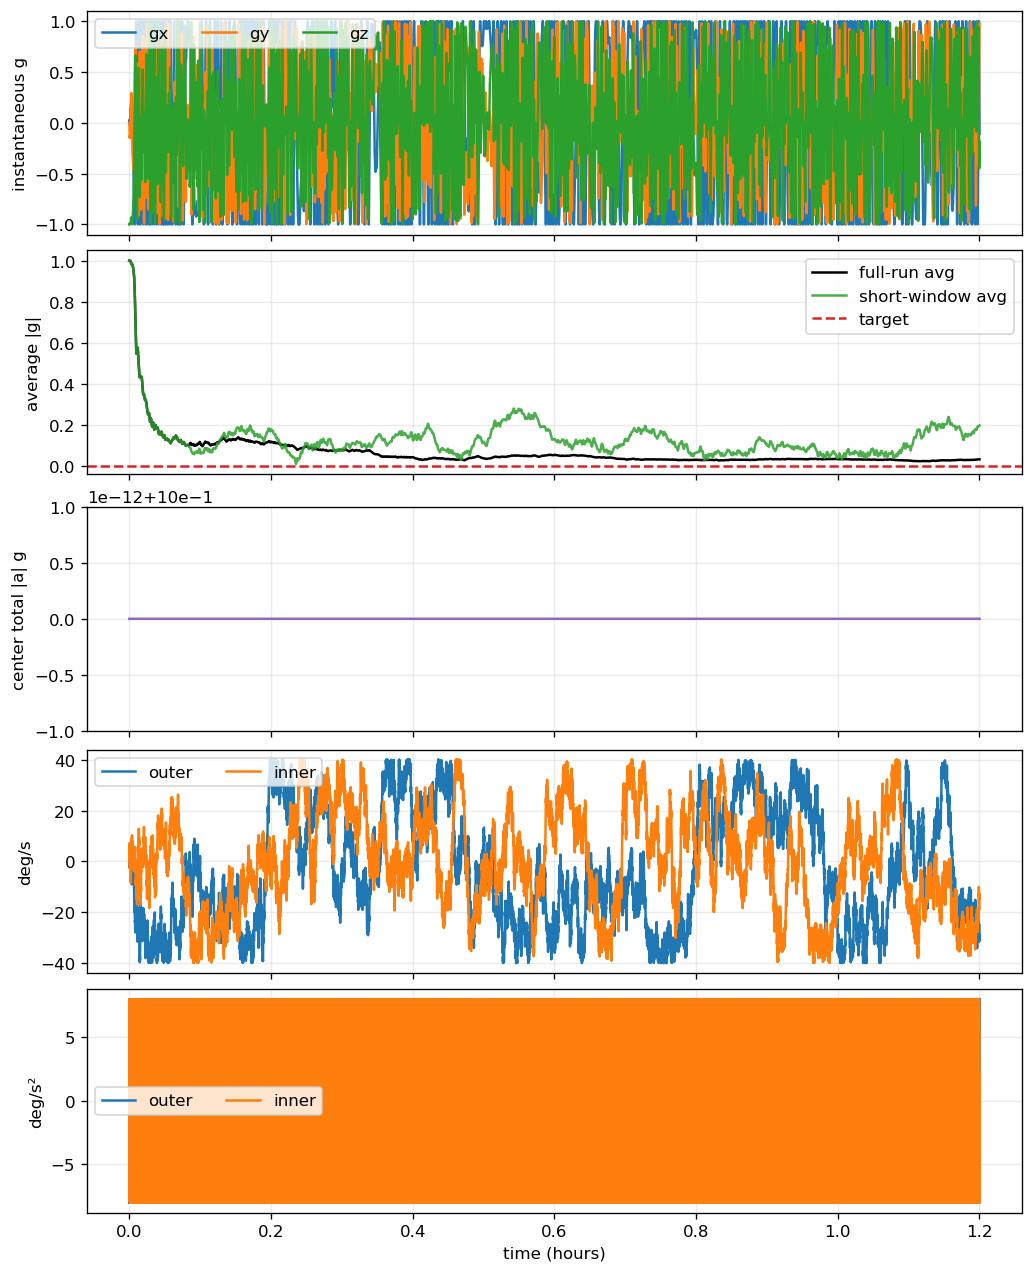

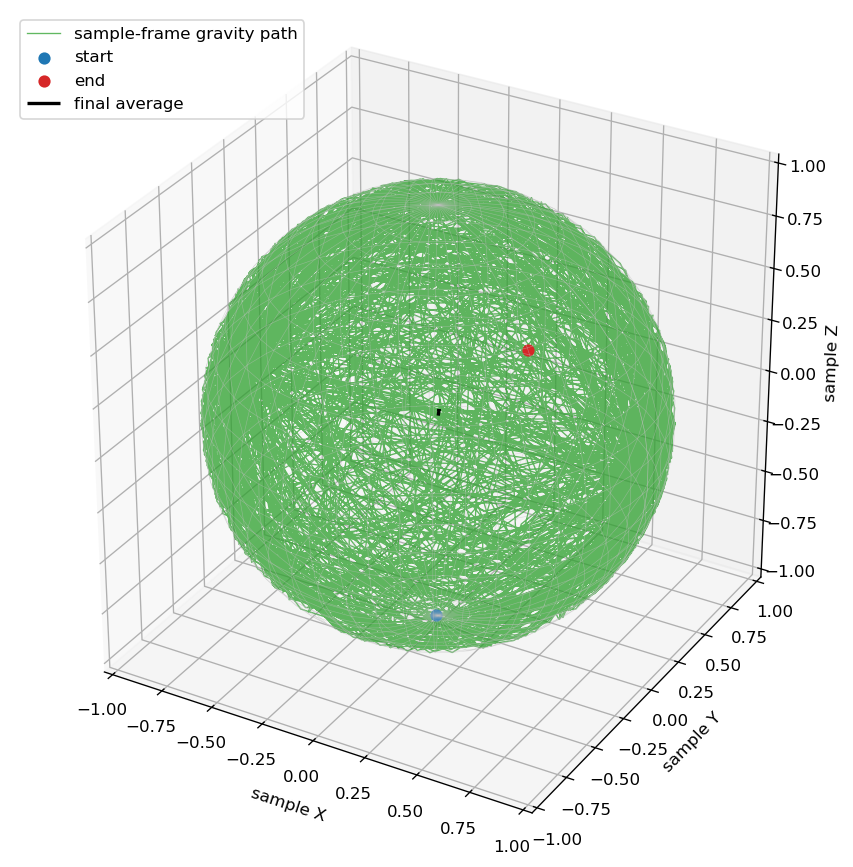

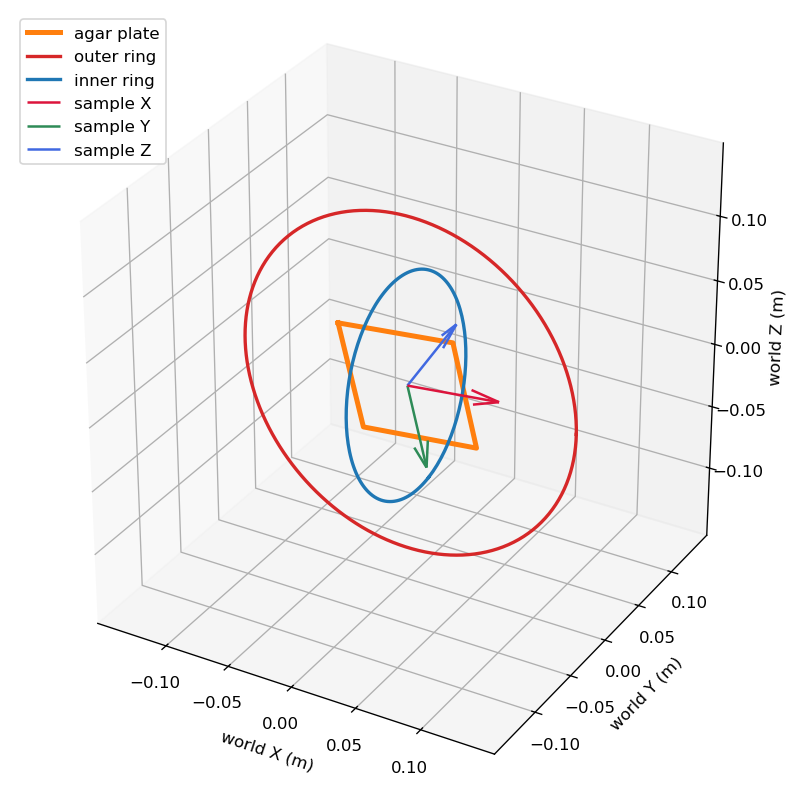

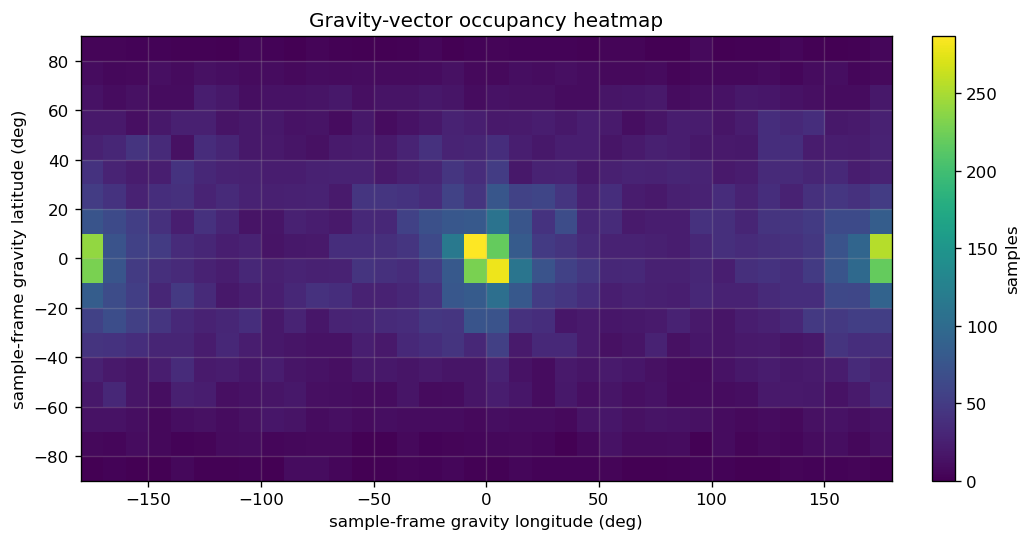

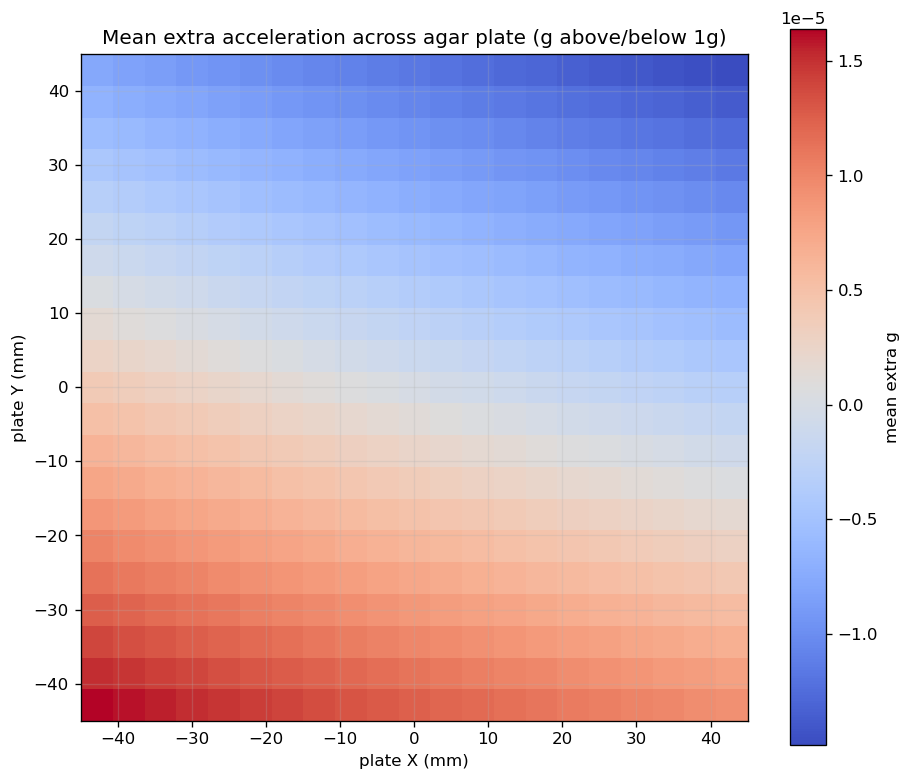

In [72]:
# -----------------------------------------------------------------------------
# MAKE FIGURES
# -----------------------------------------------------------------------------
# These commands display the main plots in the notebook.
# If you only want one figure, run only that line.

# Time series: gravity components, running average, acceleration, motor speeds.
fig1 = plot_time_series(df, cfg)
plt.show()

# 3D gravity path: where gravity points in the sample frame over time.
fig2 = plot_gravity_sphere(df, meta)
plt.show()

# 3D gimbal/plate snapshot at the final simulated time point.
fig3 = plot_gimbal_3d(df, cfg)
plt.show()

# 2D heatmap of how often the gravity vector visited each longitude/latitude bin.
fig4 = plot_orientation_heatmap(meta)
plt.show()

# Plate force map: checks whether different positions on the plate see extra acceleration.
fig5 = plot_force_map(df, meta)
plt.show()

In [73]:
# -----------------------------------------------------------------------------
# EXPORT FILES TO YOUR COMPUTER
# -----------------------------------------------------------------------------
# This is the main path-related cell.
# By default, Path("rpm_notebook_outputs") creates/uses a folder beside this notebook.
#
# CHANGE THIS ON ANOTHER COMPUTER if you want files somewhere specific.
# Examples:
#   out_dir = Path("/Users/yourname/Desktop/rpm_results")      # macOS
#   out_dir = Path("C:/Users/yourname/Desktop/rpm_results")   # Windows
#   out_dir = Path("rpm_notebook_outputs")                    # relative folder, safest default
out_dir = Path("rpm_notebook_outputs")
out_dir.mkdir(exist_ok=True)

# CSV files can be opened in Excel, Numbers, Google Sheets, or Python.
df.to_csv(out_dir / "rpm_simulation_timeseries.csv", index=False)
points.to_csv(out_dir / "sample_point_analysis.csv", index=False)
validation.to_frame("value").to_csv(out_dir / "validation_metrics.csv")
windows.to_csv(out_dir / "moving_window_validation.csv", index=False)

# Builder-facing files: command schedule, controller pseudocode, and a PDF report.
schedule_path = export_command_schedule(df, cfg, out_dir / "rpm_command_schedule.csv")
pseudocode_path = export_pseudocode(cfg, out_dir / "rpm_controller_pseudocode.txt")
pdf_path = export_pdf_report(df, meta, point_summary, out_dir / "rpm_notebook_report.pdf")
biology_bundle_path = export_biology_research_bundle(df, meta, point_summary, out_dir / "biology_research_bundle")

print("Saved outputs in:", out_dir.resolve())
print(schedule_path)
print(pseudocode_path)
print(pdf_path)
print(biology_bundle_path)

Saved outputs in: /Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs
/Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs/rpm_command_schedule.csv
/Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs/rpm_controller_pseudocode.txt
/Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs/rpm_notebook_report.pdf
/Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs/biology_research_bundle


## Optional Interactive Dashboard

This final section is optional. It creates sliders and dropdowns if `ipywidgets` is installed.

If this cell does not work on someone else's computer, the simplest fix is usually:

```bash
pip install ipywidgets
```

If widgets still do not display, skip this section. The main notebook workflow above still works.

In [74]:
# -----------------------------------------------------------------------------
# DASHBOARD_EXPLANATION
# OPTIONAL INTERACTIVE DASHBOARD
# -----------------------------------------------------------------------------
# This cell is convenience UI only. It builds dropdowns/sliders so you can test
# scenarios without editing code. The rest of the notebook does not depend on it.
if WIDGETS_AVAILABLE:
    scenario = widgets.Dropdown(options=[("Microgravity", "micro"), ("Moon", "biased_moon"), ("Mars", "biased_mars"), ("Static", "static"), ("Random", "random")], value="micro", description="Scenario")
    duration = widgets.FloatLogSlider(value=0.01, base=10, min=-4, max=1, step=0.1, description="Days")
    target = widgets.FloatSlider(value=0.0, min=0, max=1, step=0.001, description="Target g")
    settle = widgets.FloatSlider(value=300.0, min=30.0, max=900.0, step=30.0, description="Settle s")
    min_spin = widgets.FloatSlider(value=8.0, min=0.0, max=30.0, step=1.0, description="Min spin")
    plate = widgets.FloatSlider(value=130, min=20, max=200, step=1, description="Plate mm")
    inner = widgets.FloatSlider(value=160, min=50, max=400, step=1, description="Inner mm")
    outer = widgets.FloatSlider(value=260, min=80, max=600, step=1, description="Outer mm")
    max_w = widgets.FloatSlider(value=40, min=1, max=40, step=1, description="Max deg/s")
    max_a = widgets.FloatSlider(value=6, min=0.5, max=40, step=0.5, description="Max deg/s²")
    run_button = widgets.Button(description="Run simulation", button_style="primary")
    out = widgets.Output()

    def on_run(_):
        with out:
            clear_output(wait=True)
            if scenario.value == "biased_moon":
                c = preset_config("moon")
            elif scenario.value == "biased_mars":
                c = preset_config("mars")
            else:
                c = RPMConfig(scenario=scenario.value)
            # If the slider asks for a nonzero custom target, use biased
            # partial-gravity mode even if the dropdown started at Microgravity.
            scenario_name = c.scenario
            if target.value > 1e-6:
                scenario_name = "biased"
            c = c.copy(duration_days=duration.value, target_g=target.value,
                       scenario=scenario_name,
                       target_settle_s=settle.value,
                       min_continuous_spin_deg_s=min_spin.value,
                       plate_side_mm=plate.value, inner_rotator_diameter_mm=inner.value,
                       outer_rotator_diameter_mm=outer.value,
                       max_angular_velocity_deg_s=max_w.value,
                       max_angular_acceleration_deg_s2=max_a.value)
            local_df, local_meta = run_experiment(c, seed=11, fast=True, progress=False)
            val, win = target_validation(local_df, local_meta)
            local_biology = biological_exposure_report(local_df, local_meta)
            local_warnings = simulation_warnings(local_df, local_meta)
            local_quality = quality_score(local_df, local_meta)
            display(val.to_frame("value"))
            display(win)
            display(local_biology)
            display(local_warnings)
            display(local_quality.to_frame("value"))
            display(plot_time_series(local_df, c)); plt.show()
            display(plot_gravity_sphere(local_df, local_meta)); plt.show()

    run_button.on_click(on_run)
    display(widgets.VBox([
        widgets.HBox([scenario, duration, target]),
        widgets.HBox([settle, min_spin]),
        widgets.HBox([plate, inner, outer]),
        widgets.HBox([max_w, max_a, run_button]),
        out,
    ]))
else:
    print("ipywidgets is not installed in this Python environment. The non-interactive cells above still work.")